CELL 1 — Install Libraries

In [1]:
# Run only once if needed
!pip install xgboost shap lime scikit-learn matplotlib seaborn pandas numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


CELL 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CELL 3 — Load Dataset

In [3]:
df = pd.read_csv("economic_resilience_coastal_landlocked_india_1980_2025.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (828, 51)


,State,Year,Region_Type,Is_Coastal,Time_Trend_Index,Decade,Post_Liberalization,Post_2000_Infrastructure_Acceleration,Post_2010_Climate_Risk_Intensification,GDP_Growth_Rate,...,Annual_Disaster_Loss_Rate,Climate_Vulnerability_Index,Ease_of_Doing_Business_Proxy,Policy_Reform_Index,Public_Capital_Expenditure_Index,GDP_Growth_Smoothed_3Y,Economic_Resilience_Index,Economic_Resilience_Class,Coastal_Trade_Interaction,Coastal_Climate_Interaction
0,Andhra Pradesh,1980,Coastal,1,1,1980s,0,0,0,6.72,...,2.24,36.34,44.69,31.98,35.04,6.720000,19.70,Low,60.18,36.34
1,Andhra Pradesh,1981,Coastal,1,2,1980s,0,0,0,6.82,...,2.31,35.37,46.16,27.68,36.70,6.770000,18.99,Low,54.36,35.37
2,Andhra Pradesh,1982,Coastal,1,3,1980s,0,0,0,5.50,...,2.10,34.51,44.90,29.31,34.73,6.346667,17.89,Low,56.11,34.51
3,Andhra Pradesh,1983,Coastal,1,4,1980s,0,0,0,5.82,...,2.33,34.37,43.66,30.95,33.98,6.046667,17.99,Low,56.61,34.37
4,Andhra Pradesh,1984,Coastal,1,5,1980s,0,0,0,7.01,...,1.91,34.66,50.25,29.01,40.67,6.110000,20.78,Low,58.25,34.66


CELL 4 — Basic Checks

In [4]:
print(df.info())
print("\nClass Distribution:")
print(df["Economic_Resilience_Class"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 828 entries, 0 to 827
Data columns (total 51 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   State                                   828 non-null    str    
 1   Year                                    828 non-null    int64  
 2   Region_Type                             828 non-null    str    
 3   Is_Coastal                              828 non-null    int64  
 4   Time_Trend_Index                        828 non-null    int64  
 5   Decade                                  828 non-null    str    
 6   Post_Liberalization                     828 non-null    int64  
 7   Post_2000_Infrastructure_Acceleration   828 non-null    int64  
 8   Post_2010_Climate_Risk_Intensification  828 non-null    int64  
 9   GDP_Growth_Rate                         828 non-null    float64
 10  GSDP_Constant_Price                     828 non-null    float64
 11  GSDP

CELL 5 — Quick EDA: Class Distribution

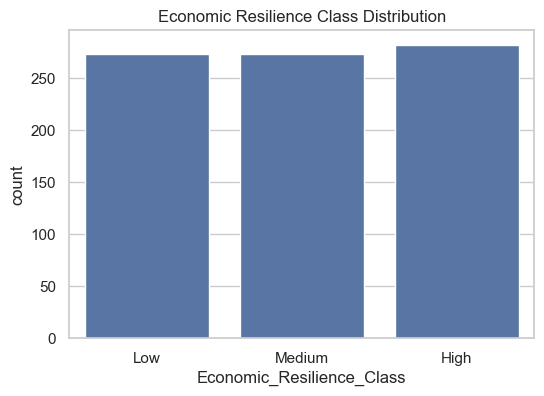

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Economic_Resilience_Class", order=["Low", "Medium", "High"])
plt.title("Economic Resilience Class Distribution")
plt.show()

CELL 6 — Coastal vs Landlocked Distribution by Class

Economic_Resilience_Class  High  Low  Medium
Region_Type                                 
Coastal                     196   84     134
Landlocked                   86  189     139


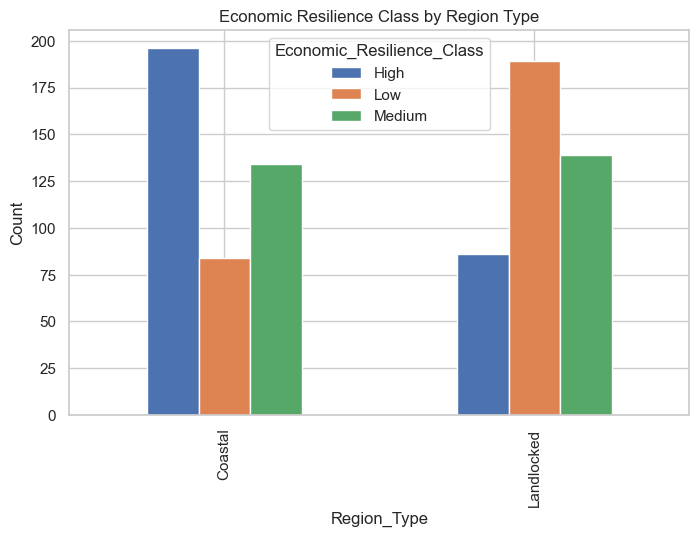

In [6]:
cross_tab = pd.crosstab(df["Region_Type"], df["Economic_Resilience_Class"])
print(cross_tab)

cross_tab.plot(kind="bar", figsize=(8,5))
plt.title("Economic Resilience Class by Region Type")
plt.ylabel("Count")
plt.show()

CELL 7 — Average ERI by Region Type

  Region_Type  Economic_Resilience_Index
0     Coastal                  37.077029
1  Landlocked                  28.693454


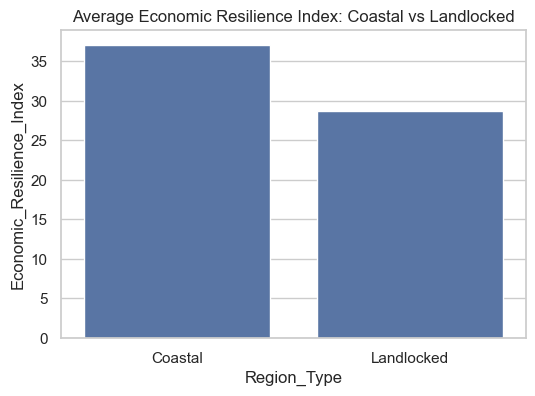

In [7]:
eri_region = df.groupby("Region_Type")["Economic_Resilience_Index"].mean().reset_index()
print(eri_region)

plt.figure(figsize=(6,4))
sns.barplot(data=eri_region, x="Region_Type", y="Economic_Resilience_Index")
plt.title("Average Economic Resilience Index: Coastal vs Landlocked")
plt.show()

CELL 8 — Trend of ERI Over Time

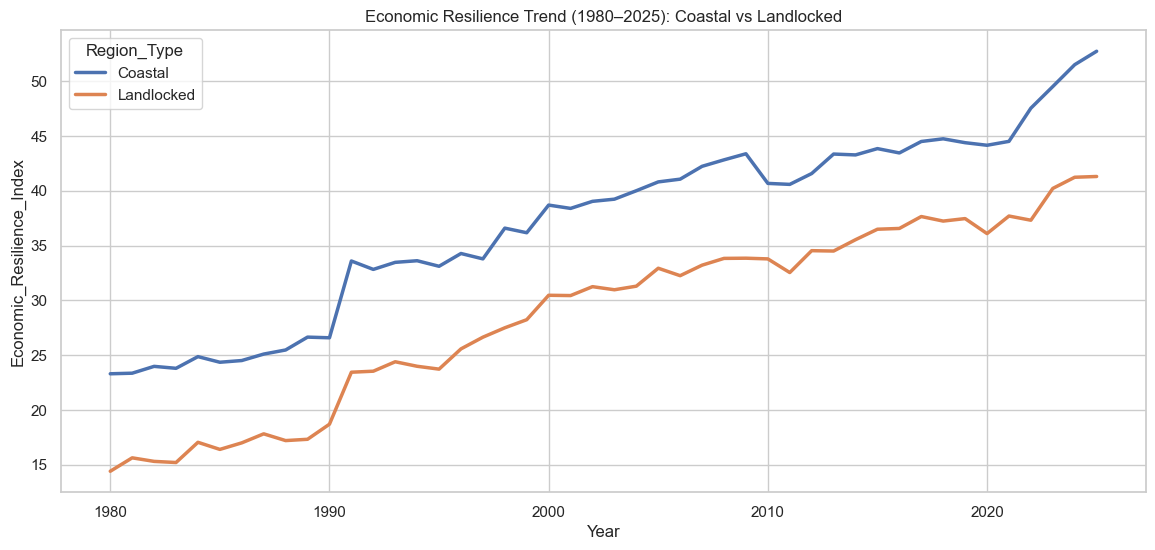

In [8]:
trend_df = df.groupby(["Year", "Region_Type"])["Economic_Resilience_Index"].mean().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=trend_df, x="Year", y="Economic_Resilience_Index", hue="Region_Type", linewidth=2.5)
plt.title("Economic Resilience Trend (1980–2025): Coastal vs Landlocked")
plt.show()

CELL 9 — Select Features

In [9]:
feature_cols = [
    "State",
    "Year",
    "Region_Type",
    "Is_Coastal",
    "Time_Trend_Index",
    "Post_Liberalization",
    "Post_2000_Infrastructure_Acceleration",
    "Post_2010_Climate_Risk_Intensification",
    "Industrial_Output_Index",
    "Services_Share",
    "Agriculture_Share",
    "Manufacturing_Share",
    "Trade_Connectivity_Index",
    "Export_Intensity",
    "Tourism_Revenue_Index",
    "FDI_Attractiveness_Index",
    "Road_Density",
    "Rail_Density",
    "Port_Access_Index",
    "Logistics_Connectivity_Index",
    "Urbanization_Rate",
    "Electricity_Access_Rate",
    "Internet_Penetration_Rate",
    "Infrastructure_Composite_Index",
    "Literacy_Rate",
    "Higher_Education_Enrollment",
    "Health_Index",
    "Labor_Force_Participation",
    "Unemployment_Rate",
    "Flood_Risk_Index",
    "Cyclone_Exposure_Index",
    "Drought_Risk_Index",
    "Heat_Stress_Index",
    "Coastal_Erosion_Risk",
    "Land_Submergence_Risk_Index",
    "Sea_Level_Rise_Exposure",
    "Annual_Disaster_Loss_Rate",
    "Climate_Vulnerability_Index",
    "Ease_of_Doing_Business_Proxy",
    "Policy_Reform_Index",
    "Public_Capital_Expenditure_Index",
    "GDP_Growth_Smoothed_3Y",
    "Coastal_Trade_Interaction",
    "Coastal_Climate_Interaction"
]

target_col = "Economic_Resilience_Class"

df_model = df[feature_cols + [target_col]].copy()

print("Model Data Shape:", df_model.shape)

Model Data Shape: (828, 45)


CELL 10 — Encode Target

In [10]:
target_encoder = LabelEncoder()
df_model[target_col] = target_encoder.fit_transform(df_model[target_col])

print("Class Mapping:")
for i, cls in enumerate(target_encoder.classes_):
    print(f"{cls} -> {i}")

Class Mapping:
High -> 0
Low -> 1
Medium -> 2


CELL 11 — One-Hot Encode Categorical Features

In [11]:
df_model = pd.get_dummies(df_model, columns=["State", "Region_Type"], drop_first=True)

print("Shape after encoding:", df_model.shape)
df_model.head()

Shape after encoding: (828, 61)


,Year,Is_Coastal,Time_Trend_Index,Post_Liberalization,Post_2000_Infrastructure_Acceleration,Post_2010_Climate_Risk_Intensification,Industrial_Output_Index,Services_Share,Agriculture_Share,Manufacturing_Share,...,State_Kerala,State_Madhya Pradesh,State_Maharashtra,State_Odisha,State_Punjab,State_Rajasthan,State_Tamil Nadu,State_Uttar Pradesh,State_West Bengal,Region_Type_Landlocked
0,1980,1,1,0,0,0,68.60,46.68,30.07,24.25,...,False,False,False,False,False,False,False,False,False,False
1,1981,1,2,0,0,0,63.87,46.55,26.45,23.22,...,False,False,False,False,False,False,False,False,False,False
2,1982,1,3,0,0,0,68.11,45.60,28.65,23.23,...,False,False,False,False,False,False,False,False,False,False
3,1983,1,4,0,0,0,59.67,46.90,27.83,22.26,...,False,False,False,False,False,False,False,False,False,False
4,1984,1,5,0,0,0,67.95,46.51,26.21,22.81,...,False,False,False,False,False,False,False,False,False,False


CELL 12 — Define X and y

In [12]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (828, 60)
y shape: (828,)


In [28]:
# Convert boolean columns to int
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Convert everything to numeric safely
X = X.apply(pd.to_numeric, errors='coerce')

# Check for any remaining missing values after coercion
print("Missing values after numeric conversion:", X.isnull().sum().sum())

# Fill any accidental NaNs (should usually be 0 or very few)
X = X.fillna(0)

print("All feature dtypes after conversion:")
print(X.dtypes.value_counts())

Missing values after numeric conversion: 0
All feature dtypes after conversion:
float64    36
int64      24
Name: count, dtype: int64


CELL 13 — Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (662, 60)
Test shape: (166, 60)


CELL 14 — Evaluation Function

In [30]:
def evaluate_classifier(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    
    print(f"{name}")
    print("-" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print()
    
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    }

CELL 15 — Logistic Regression (Baseline)

In [31]:
log_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_results = evaluate_classifier("Logistic Regression", log_model, X_test, y_test)

Logistic Regression
------------------------------------------------------------
Accuracy : 0.9699
Precision: 0.9710
Recall   : 0.9699
F1 Score : 0.9701



CELL 16 — Random Forest Classifier

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=18,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_classifier("Random Forest Classifier", rf_model, X_test, y_test)

Random Forest Classifier
------------------------------------------------------------
Accuracy : 0.9398
Precision: 0.9398
Recall   : 0.9398
F1 Score : 0.9396



CELL 17 — XGBoost Classifier (Main Model)

In [33]:
xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

xgb_results = evaluate_classifier("XGBoost Classifier", xgb_model, X_test, y_test)

XGBoost Classifier
------------------------------------------------------------
Accuracy : 0.9277
Precision: 0.9275
Recall   : 0.9275
F1 Score : 0.9275



CELL 18 — Compare Model Performance

In [34]:
results_df = pd.DataFrame([log_results, rf_results, xgb_results]).sort_values(by="F1_Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.969880,0.970951,0.969913,0.970069
1,Random Forest Classifier,0.939759,0.939807,0.939827,0.939610
2,XGBoost Classifier,0.927711,0.927489,0.927489,0.927489


CELL 19 — Plot Model Comparison

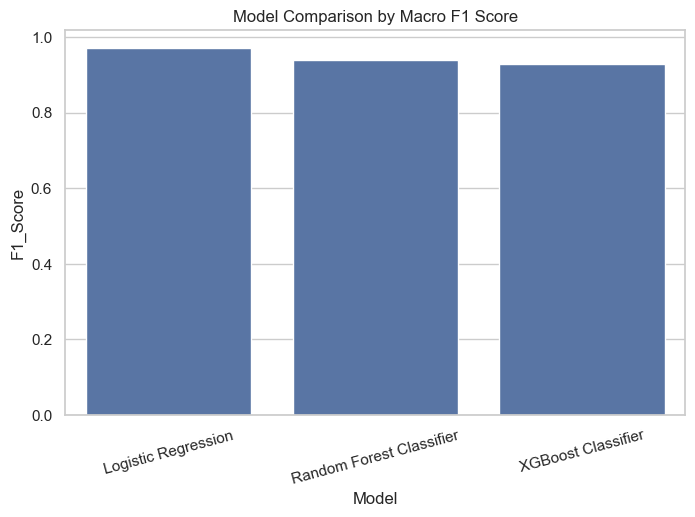

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="F1_Score")
plt.title("Model Comparison by Macro F1 Score")
plt.xticks(rotation=15)
plt.show()

CELL 20 — Classification Report (XGBoost)

In [36]:
y_pred_xgb = xgb_model.predict(X_test)

print("Classification Report - XGBoost")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=target_encoder.classes_
))

Classification Report - XGBoost
              precision    recall  f1-score   support

        High       0.96      0.96      0.96        56
         Low       0.93      0.93      0.93        55
      Medium       0.89      0.89      0.89        55

    accuracy                           0.93       166
   macro avg       0.93      0.93      0.93       166
weighted avg       0.93      0.93      0.93       166



CELL 21 — Confusion Matrix (XGBoost)

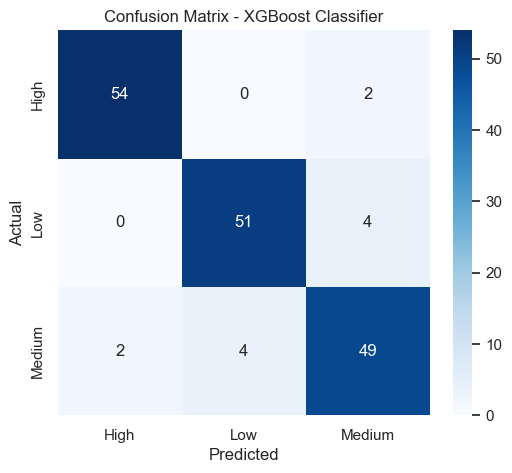

In [37]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix - XGBoost Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

CELL 22 — Random Forest Feature Importance

In [38]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(20)

,Feature,Importance
22,Literacy_Rate,0.114238
19,Electricity_Access_Rate,0.095943
36,Ease_of_Doing_Business_Proxy,0.085216
23,Higher_Education_Enrollment,0.083873
24,Health_Index,0.055219
14,Road_Density,0.054811
13,FDI_Attractiveness_Index,0.049413
37,Policy_Reform_Index,0.039651
38,Public_Capital_Expenditure_Index,0.034798
10,Trade_Connectivity_Index,0.033197


CELL 23 — Plot RF Feature Importance

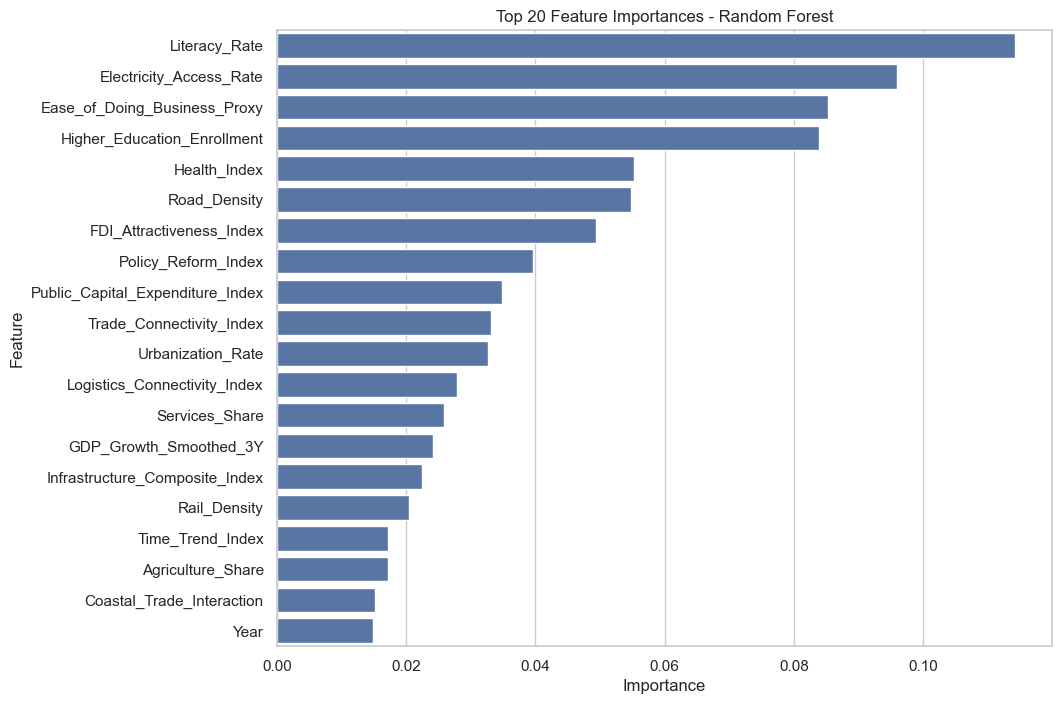

In [39]:
plt.figure(figsize=(10,8))
sns.barplot(data=rf_importance.head(20), x="Importance", y="Feature")
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

CELL 24 — XGBoost Feature Importance

In [40]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(20)

,Feature,Importance
36,Ease_of_Doing_Business_Proxy,0.215392
22,Literacy_Rate,0.196679
19,Electricity_Access_Rate,0.084574
47,State_Haryana,0.044191
23,Higher_Education_Enrollment,0.032393
37,Policy_Reform_Index,0.023634
0,Year,0.022668
2,Time_Trend_Index,0.020107
20,Internet_Penetration_Rate,0.019217
10,Trade_Connectivity_Index,0.018942


CELL 25 — Plot XGB Feature Importance

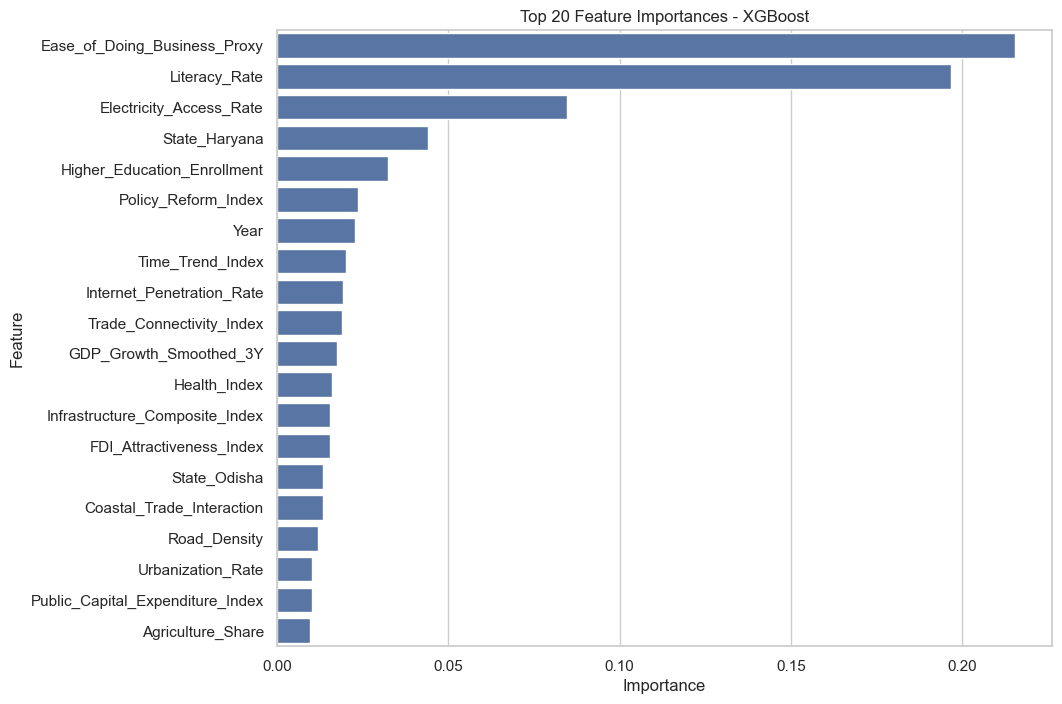

In [41]:
plt.figure(figsize=(10,8))
sns.barplot(data=xgb_importance.head(20), x="Importance", y="Feature")
plt.title("Top 20 Feature Importances - XGBoost")
plt.show()

CELL 26 — SHAP for XGBoost (Main XAI)

In [42]:
explainer_xgb = shap.Explainer(xgb_model, X_train)
shap_values_xgb = explainer_xgb(X_test)

print("SHAP values computed successfully.")

 94%|=================== | 469/498 [00:13<00:00]       

SHAP values computed successfully.


CELL 27 — SHAP Summary Plot (Class 0 = Low)

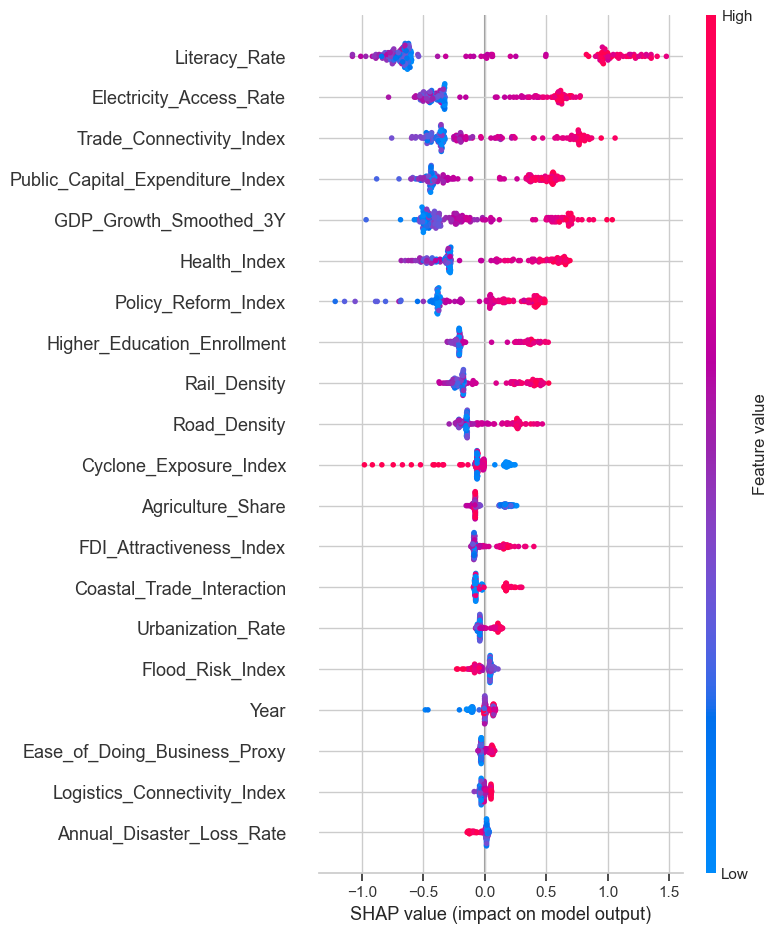

In [43]:
# Example: class 0 = Low (check your mapping)
shap.summary_plot(shap_values_xgb[:, :, 0], X_test)

CELL 28 — SHAP Bar Plot (Class 0 = Low)

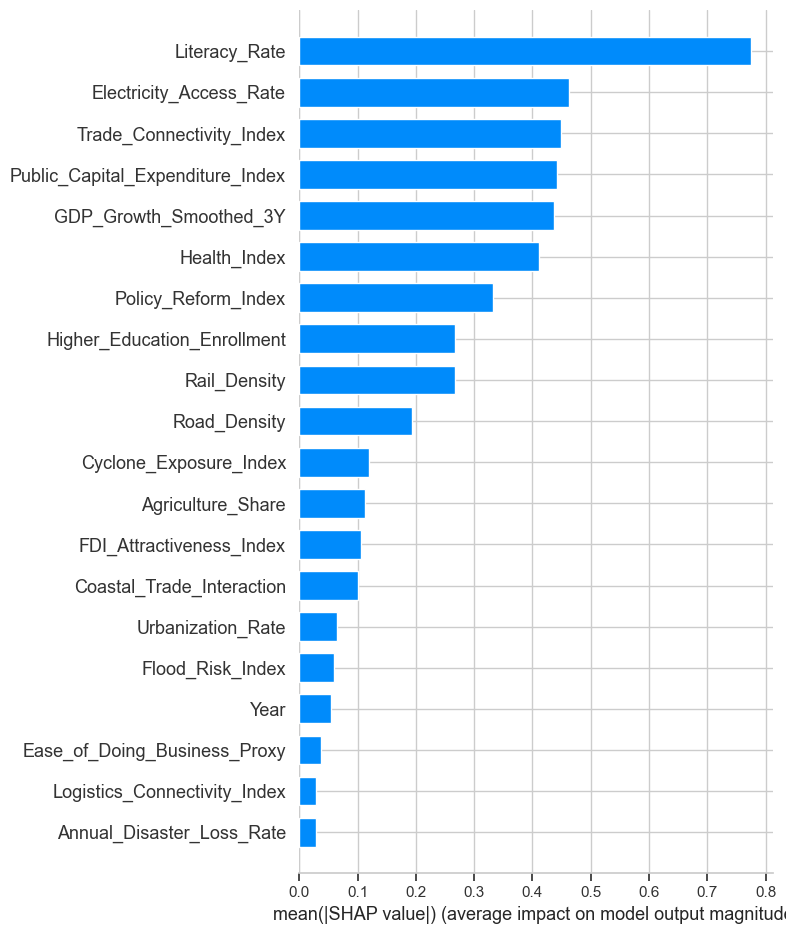

In [44]:
shap.summary_plot(shap_values_xgb[:, :, 0], X_test, plot_type="bar")

CELL 29 — SHAP Summary Plot (Class 2 = High)

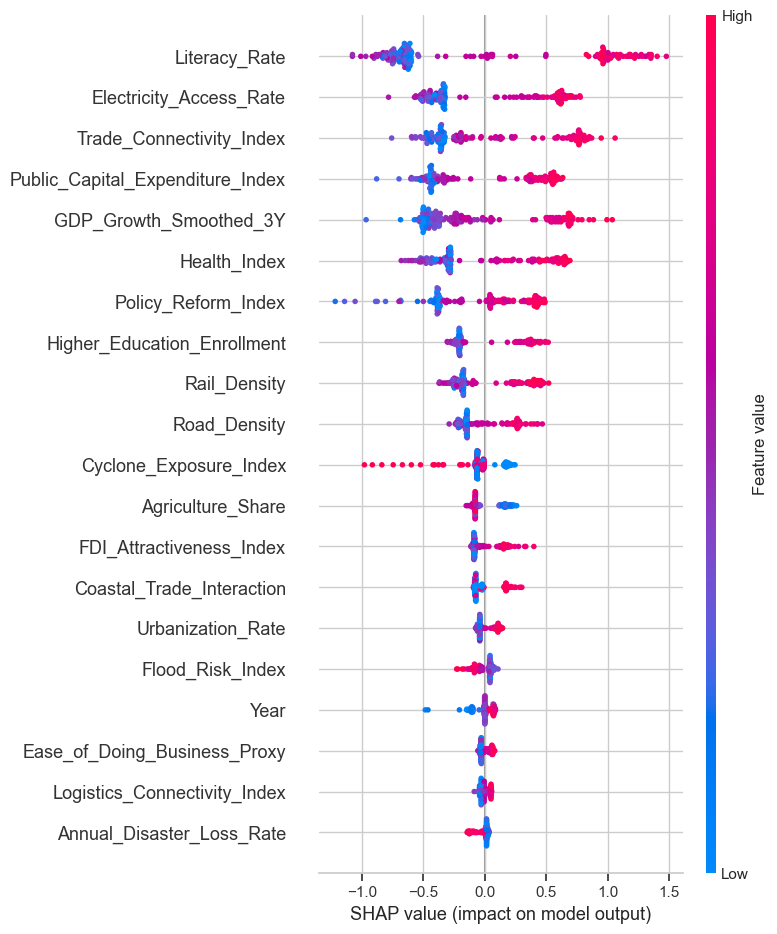

In [45]:
# Check mapping from Cell 10
# If High = 0/1/2 depends on label encoder output
high_class_index = list(target_encoder.classes_).index("High")

shap.summary_plot(shap_values_xgb[:, :, high_class_index], X_test)

CELL 30 — SHAP Bar Plot (High Class)

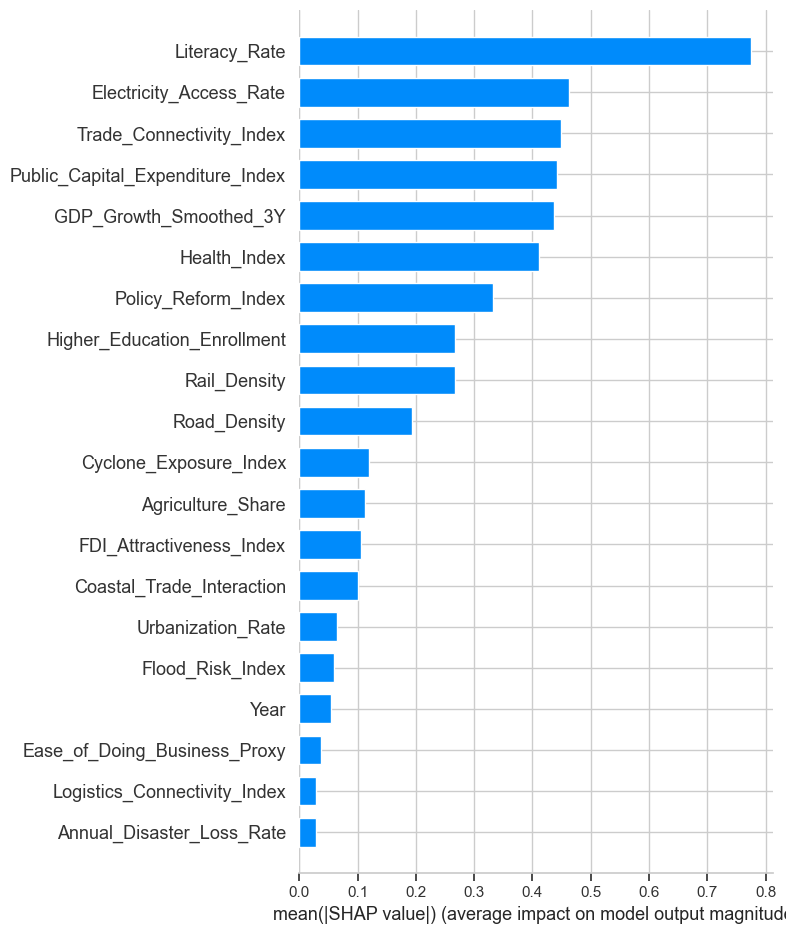

In [46]:
shap.summary_plot(shap_values_xgb[:, :, high_class_index], X_test, plot_type="bar")

CELL 31 — SHAP Waterfall Plot (SAFE)

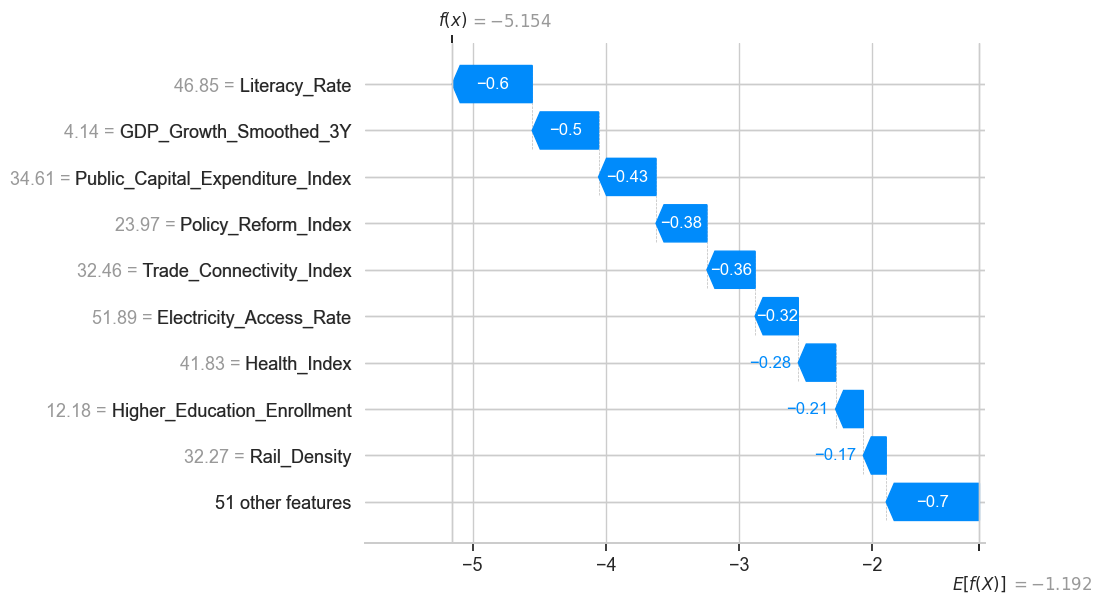

In [47]:
sample_idx = 5
shap.plots.waterfall(shap_values_xgb[sample_idx, :, high_class_index])

CELL 32 — LIME for XGBoost (SAFE VERSION)

In [48]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=target_encoder.classes_.tolist(),
    mode="classification"
)

sample_idx = 10

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

print("LIME Explanation (Top 10 Features):")
for feature, contribution in lime_exp.as_list():
    print(f"{feature}: {contribution:.4f}")

LIME Explanation (Top 10 Features):
Public_Capital_Expenditure_Index <= 40.02: 0.2246
Policy_Reform_Index <= 36.43: 0.1948
Higher_Education_Enrollment <= 22.68: 0.0819
Trade_Connectivity_Index <= 52.68: 0.0625
Tourism_Revenue_Index <= 24.93: 0.0580
Export_Intensity <= 28.53: 0.0549
State_Kerala <= 0.00: 0.0349
Year <= 1991.00: 0.0281
68.86 < Electricity_Access_Rate <= 75.73: 0.0276
State_Bihar <= 0.00: 0.0269


CELL 33 — LIME Plot

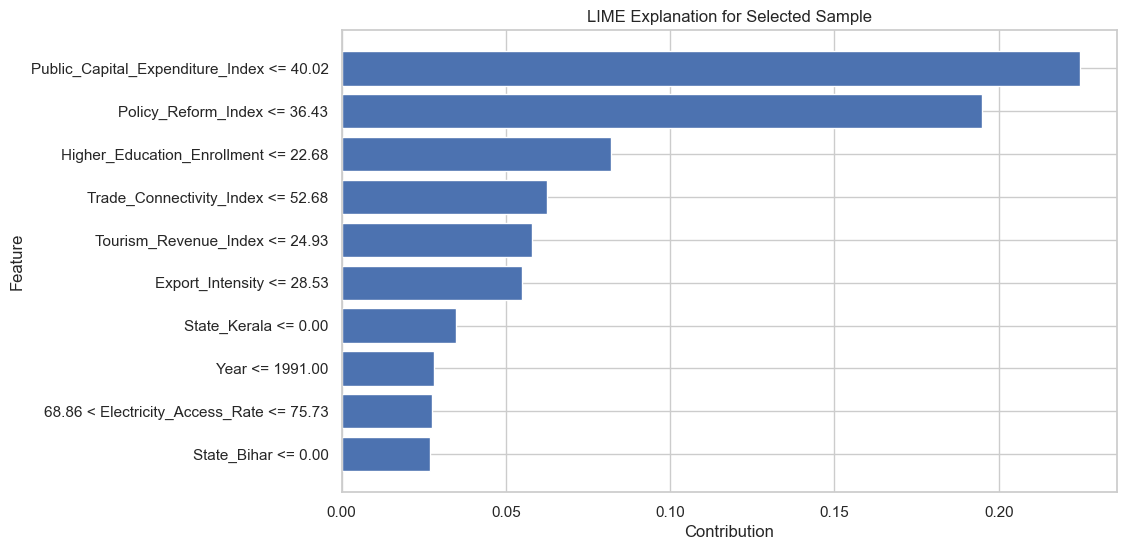

In [49]:
lime_df = pd.DataFrame(lime_exp.as_list(), columns=["Feature", "Contribution"])
lime_df = lime_df.sort_values(by="Contribution", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(lime_df["Feature"], lime_df["Contribution"])
plt.title("LIME Explanation for Selected Sample")
plt.xlabel("Contribution")
plt.ylabel("Feature")
plt.show()

CELL 34 — Coastal-Only Subgroup Analysis

In [50]:
df_coastal = df[df["Region_Type"] == "Coastal"].copy()

coastal_features = feature_cols + [target_col]
df_coastal_model = df_coastal[coastal_features].copy()

# Encode target
df_coastal_model[target_col] = target_encoder.transform(df_coastal_model[target_col])

# One-hot encode
df_coastal_model = pd.get_dummies(df_coastal_model, columns=["State", "Region_Type"], drop_first=True)

X_coastal = df_coastal_model.drop(columns=[target_col])
y_coastal = df_coastal_model[target_col]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_coastal, y_coastal,
    test_size=0.2,
    random_state=42,
    stratify=y_coastal
)

rf_coastal = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_coastal.fit(X_train_c, y_train_c)

coastal_results = evaluate_classifier("Random Forest (Coastal Only)", rf_coastal, X_test_c, y_test_c)

Random Forest (Coastal Only)
------------------------------------------------------------
Accuracy : 0.9036
Precision: 0.9042
Recall   : 0.8981
F1 Score : 0.9004



CELL 35 — Coastal Feature Importance

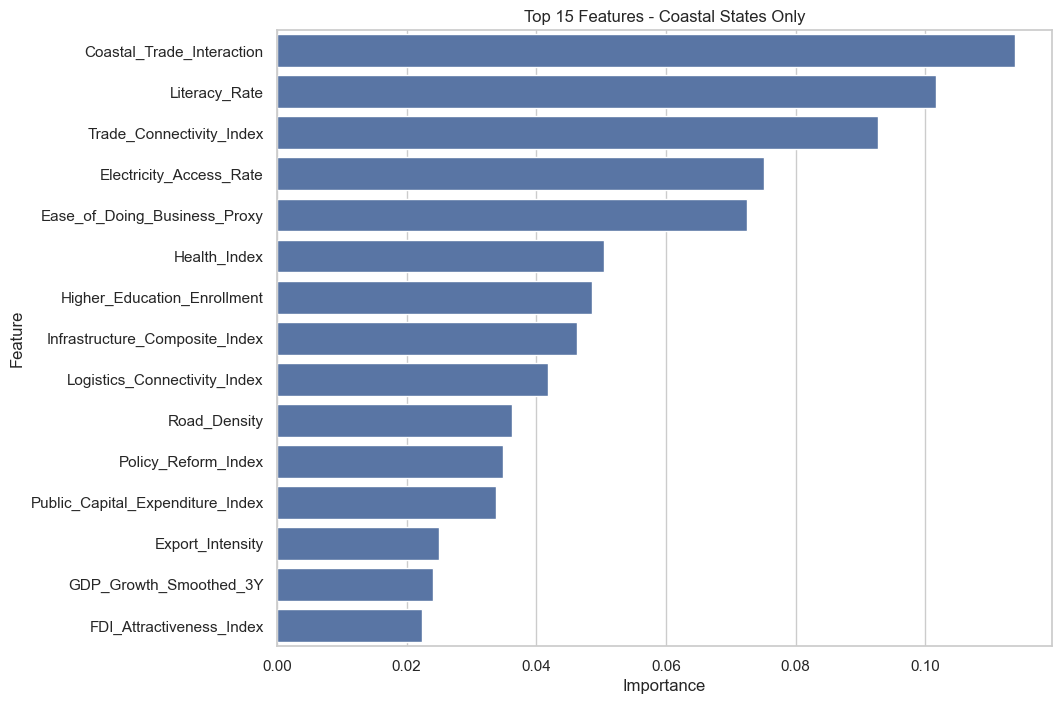

,Feature,Importance
40,Coastal_Trade_Interaction,0.113865
22,Literacy_Rate,0.101738
10,Trade_Connectivity_Index,0.092735
19,Electricity_Access_Rate,0.075142
36,Ease_of_Doing_Business_Proxy,0.072487
24,Health_Index,0.050387
23,Higher_Education_Enrollment,0.048610
21,Infrastructure_Composite_Index,0.046318
17,Logistics_Connectivity_Index,0.041751
14,Road_Density,0.036233


In [51]:
coastal_importance = pd.DataFrame({
    "Feature": X_train_c.columns,
    "Importance": rf_coastal.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=coastal_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Features - Coastal States Only")
plt.show()

coastal_importance.head(15)

CELL 36 — Landlocked-Only Subgroup Analysis

In [52]:
df_land = df[df["Region_Type"] == "Landlocked"].copy()

land_features = feature_cols + [target_col]
df_land_model = df_land[land_features].copy()

# Encode target
df_land_model[target_col] = target_encoder.transform(df_land_model[target_col])

# One-hot encode
df_land_model = pd.get_dummies(df_land_model, columns=["State", "Region_Type"], drop_first=True)

X_land = df_land_model.drop(columns=[target_col])
y_land = df_land_model[target_col]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_land, y_land,
    test_size=0.2,
    random_state=42,
    stratify=y_land
)

rf_land = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_land.fit(X_train_l, y_train_l)

land_results = evaluate_classifier("Random Forest (Landlocked Only)", rf_land, X_test_l, y_test_l)

Random Forest (Landlocked Only)
------------------------------------------------------------
Accuracy : 0.9518
Precision: 0.9583
Recall   : 0.9541
F1 Score : 0.9540



CELL 37 — Landlocked Feature Importance

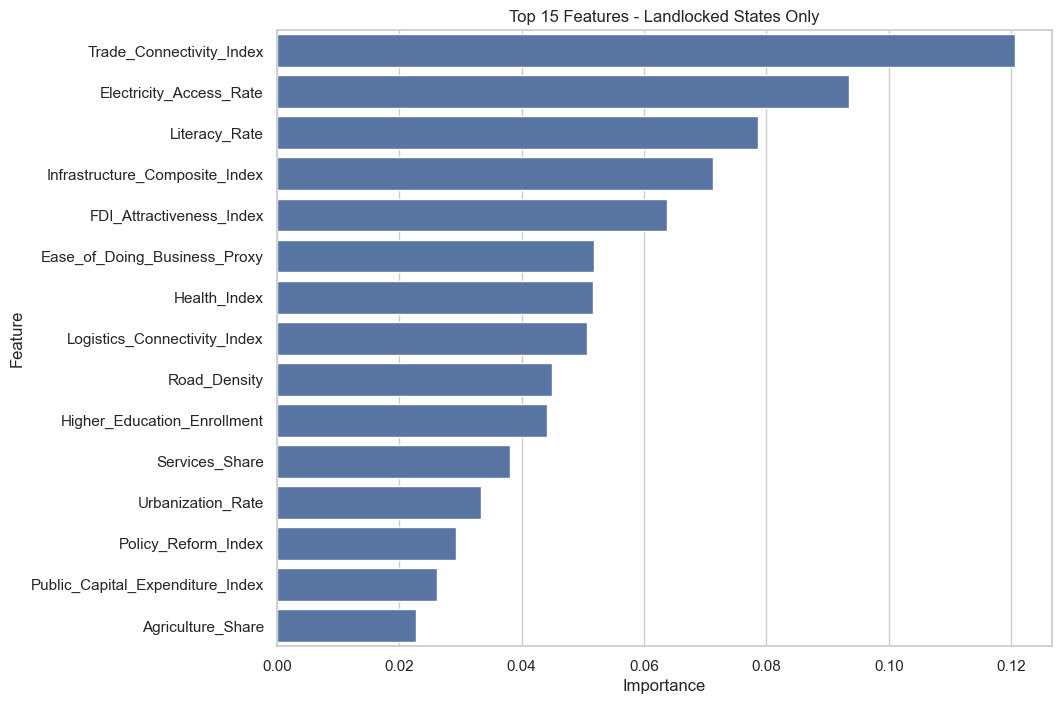

,Feature,Importance
10,Trade_Connectivity_Index,0.120632
19,Electricity_Access_Rate,0.093453
22,Literacy_Rate,0.078654
21,Infrastructure_Composite_Index,0.071335
13,FDI_Attractiveness_Index,0.063739
36,Ease_of_Doing_Business_Proxy,0.051871
24,Health_Index,0.051653
17,Logistics_Connectivity_Index,0.050629
14,Road_Density,0.044896
23,Higher_Education_Enrollment,0.044171


In [53]:
land_importance = pd.DataFrame({
    "Feature": X_train_l.columns,
    "Importance": rf_land.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=land_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Features - Landlocked States Only")
plt.show()

land_importance.head(15)

CELL 38 — Regional Comparison Table

In [54]:
regional_results = pd.DataFrame([coastal_results, land_results])
regional_results

,Model,Accuracy,Precision,Recall,F1_Score
0,Random Forest (Coastal Only),0.903614,0.904152,0.898106,0.900433
1,Random Forest (Landlocked Only),0.951807,0.958333,0.954076,0.953978


CELL 39 — Export Results

In [55]:
results_df.to_csv("classification_model_results.csv", index=False)
rf_importance.to_csv("rf_feature_importance.csv", index=False)
xgb_importance.to_csv("xgb_feature_importance.csv", index=False)
coastal_importance.to_csv("coastal_feature_importance.csv", index=False)
land_importance.to_csv("landlocked_feature_importance.csv", index=False)

print("All result files exported successfully.")

All result files exported successfully.
